In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [2]:
observations = 1000
xs = np.random.uniform(low =-10 , high=10 , size=(observations,1))
zs = np.random.uniform(low =-10 , high = 10,size =(observations,1))
inputs =np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [3]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)

(1000, 1)


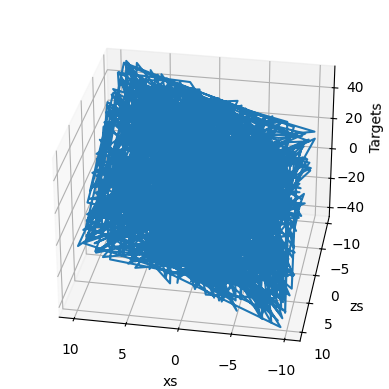

In [4]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs , zs , targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [8]:
init_range = 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1) )
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)

[[ 0.03816037]
 [-0.04149608]] [0.08360728]


In [9]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

222.75040045517466
35.250797340587276
13.812860171219505
11.021264626795608
10.338356711660639
9.906972970584327
9.517905308837678
9.147081658514379
8.79126077763813
8.449565184253693
8.121403658696579
7.806236703554036
7.503549371925869
7.212847466261568
6.933656398075342
6.665520375582304
6.40800165536354
6.1606798272539995
5.923151127951338
5.695027781849235
5.475937367976718
5.265522212005137
5.06343880232978
4.869357229272684
4.6829606464912015
4.503944753713
4.332017299953045
4.166897606401564
4.008316108204068
3.8560139143853602
3.7097423851991325
3.5692627262130965
3.43434559846701
3.3047707440671807
3.1803266266061643
3.0608100858206724
2.946026005923887
2.8357869970707217
2.729913089436006
2.62823143940616
2.5305760474047263
2.4367874868910575
2.3467126440897834
2.260204468026115
2.1771217304589436
2.097328795319782
2.020695397281171
1.9470964290930475
1.8764117373398868
1.8085259262851943
1.7433281694831027
1.6807120288495287
1.6205752808975271
1.5628197498531309
1.507351147

In [11]:
print(weights,biases)

[[ 2.00178862]
 [-3.00409462]] [4.32363452]


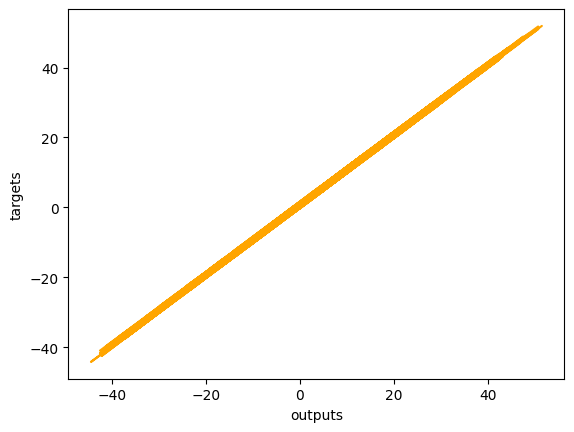

In [12]:
plt.plot(outputs, targets , color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()